# Plot the isentropes of the extended SCvH EOS

In [1]:
from __future__ import print_function
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate as interp
#from scipy import optimize
import numpy as np

In [2]:
%matplotlib widget
%config InlineBackend.figure_format = 'retina'

In [3]:
mpl.rcParams['figure.dpi'] = 100

In [4]:
def read_eos_table_dt(filename, delimiter=None):
    data = np.loadtxt(filename, delimiter=delimiter) 

    logT_table   = data[:, 0]
    logrho_table = data[:, 1]
    logP_table   = data[:, 2]
    logu_table   = data[:, 3]
    logs_table   = data[:, 4]

    # All the SCvH EOS tables are tabulated along isotherms
    logT = np.unique(logT_table)
    nT = np.size(logT)

    # For the mixture tables the number of grid points in rho the same for each isotherm
    nRho = int(np.size(logT_table)/nT)
    
    print("nT = {:} nRho = {:}".format(nT, nRho))
    
    logrho = logrho_table[0:nRho]
    
    logrho_min = np.min(logrho)
    logrho_max = np.max(logrho)
    logT_min   = np.min(logT)
    logT_max   = np.max(logT)

    print("logrho_min = {:}".format(logrho_min))
    print("logrho_max = {:}".format(logrho_max))
    print("logT_min   = {:}".format(logT_min))
    print("logT_max   = {:}".format(logT_max))
    print()

    # Split into arrays of constant T
    logP_array = np.split(logP_table, nT)
    logu_array = np.split(logu_table, nT)
    logs_array = np.split(logs_table, nT)

    # Generate 2d arrays
    logP = np.vstack(logP_array)
    logu = np.vstack(logu_array)
    logs = np.vstack(logs_array)
      
    eos_table_dt = {
        "nT":         nT,
        "nRho":       nRho,
        "logT":       logT,
        "logrho":     logrho,
        "logrho_min": logrho_min,
        "logrho_max": logrho_max,
        "logT_min":   logT_min,
        "logT_max":   logT_max,
        "logP":       logP,
        "logu":       logu,
        "logs":       logs,
    }
    
    return eos_table_dt

In [5]:
scvh_ext_dt = read_eos_table_dt("scvh_extended_dt_hydrogen_722_helium_278.data")

# At logT = 2.1 the SCvH EOS table starts
index_start_scvh = np.where(scvh_ext_dt['logT'] == 2.1)[0]

print("The SCvH EOS starts from index: {:}".format(index_start_scvh))

nT = 76 nRho = 460
logrho_min = -20.0
logrho_max = 2.95
logT_min   = 1.06
logT_max   = 7.06

The SCvH EOS starts from index: [13]


In [6]:
data = np.loadtxt("logrho_limit_pt.txt")

logT_limit = data[:,0]
logrho_limit_min = data[:,1]
logrho_limit_max = data[:,2]


[Text(0.5, 0, 'log(rho) [g cm$^{-3}$]'), Text(0, 0.5, 'log(T) [K]')]

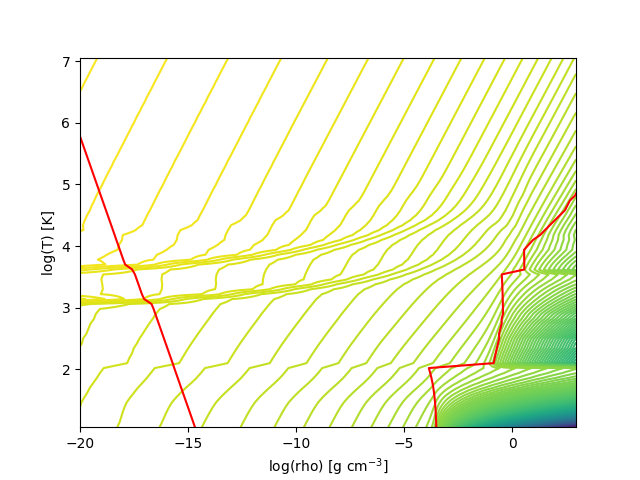

In [7]:
# Plot log(P), log(u) and log(s)
fig, ax = plt.subplots(1, 1)

#x, y = fig.get_size_inches()
#fig.set_size_inches(2*x, 3*y)

#levels = np.linspace(scvh_ext_dt['logrho_min'], scvh_ext_dt['logrho_max'], 101)
#levels = np.sort(levels)

array = np.meshgrid(scvh_ext_dt['logrho'], scvh_ext_dt['logT'])


#ax.contour(scvh_ext_dt['logrho'], scvh_ext_dt['logT'], scvh_ext_dt['logs'], levels)
ax.contour(scvh_ext_dt['logrho'], scvh_ext_dt['logT'], scvh_ext_dt['logs'], levels=200)

ax.plot(logrho_limit_min, logT_limit, color='red')
ax.plot(logrho_limit_max, logT_limit, color='red')

ax.set_xlim(scvh_ext_dt['logrho_min'], scvh_ext_dt['logrho_max'])
ax.set_ylim(scvh_ext_dt['logT_min'], scvh_ext_dt['logT_max'])

ax.set(xlabel="log(rho) [g cm$^{-3}$]", ylabel="log(T) [K]")


    
#for logT in scvh_ext_dt['logT']:
#    ax.scatter(scvh_ext_dt['logrho'], np.ones(scvh_ext_dt['nRho'])*logT, s=1)

(1.06, 2.15)

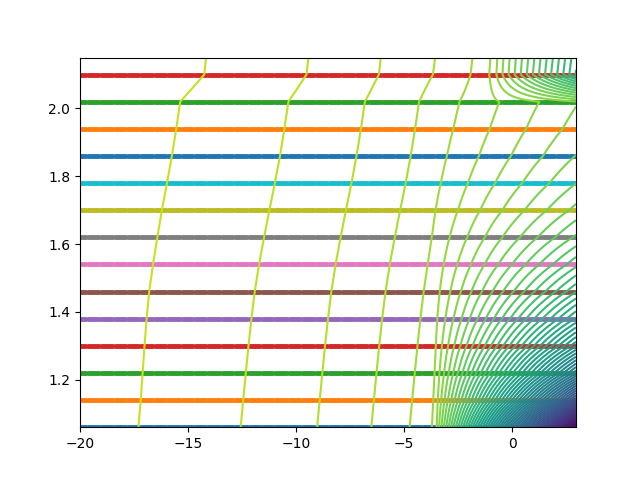

In [8]:
# Plot log(P), log(u) and log(s)
fig, ax = plt.subplots(1, 1)

#x, y = fig.get_size_inches()
#fig.set_size_inches(2*x, 3*y)

levels = np.linspace(scvh_ext_dt['logrho_min'], scvh_ext_dt['logrho_max'], 101)
levels = np.sort(levels)

array = np.meshgrid(scvh_ext_dt['logrho'], scvh_ext_dt['logT'])


#ax.contour(scvh_ext_dt['logrho'], scvh_ext_dt['logT'], scvh_ext_dt['logs'], levels)
ax.contour(scvh_ext_dt['logrho'], scvh_ext_dt['logT'], scvh_ext_dt['logs'], levels=100)

for i in range(0, 15):
#for i in range(0, scvh_ext_dt['nT']):
    logT = scvh_ext_dt['logT'][i]
    ax.scatter(scvh_ext_dt['logrho'], np.ones(scvh_ext_dt['nRho'])*logT, s=5)

ax.set_ylim(np.min(scvh_ext_dt['logT']), 2.15)
#for logT in scvh_ext_dt['logT']:
#    ax.scatter(scvh_ext_dt['logrho'], np.ones(scvh_ext_dt['nRho'])*logT, s=1)

In [9]:
index = np.min(np.where(scvh_ext_dt['logrho'] > -15.0))
print(index)
print(scvh_ext_dt['logrho'][index])

101
-14.95


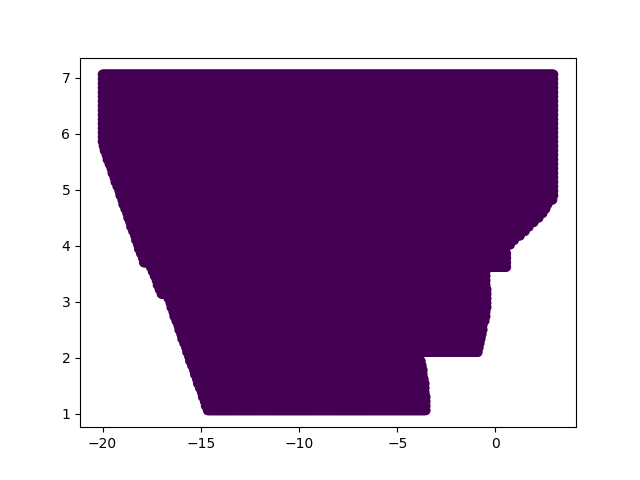

In [10]:
table_defined = np.zeros((scvh_ext_dt['nT'], scvh_ext_dt['nRho']))

for i in range(scvh_ext_dt['nT']):
    table_defined[i,np.where(scvh_ext_dt['logrho'] < logrho_limit_min[i])] = None
    table_defined[i,np.where(scvh_ext_dt['logrho'] > logrho_limit_max[i])] = None

fig, ax = plt.subplots(1, 1)

x, y = np.meshgrid(scvh_ext_dt['logrho'], scvh_ext_dt['logT'])
ax.scatter(x, y, c=table_defined)